In [159]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import torch
from tqdm.auto import tqdm
from torch.optim import Adam
import numpy as np
import numpy.typing as npt
from utils import make_unpacked_configurations

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

from sympy.combinatorics import Permutation
from sympy.combinatorics.perm_groups import PermutationGroup

from collections.abc import Iterable
import itertools


In [42]:
def vis_permutation(lat: SpinLattice, permutation: list[int]):
    lat.plot()
    for _, row in lat.sites_df.iterrows():
        plt.text(row['emb_x'] + 0.2, row['emb_y'] + 0.2, "(" + str(permutation[row['num']]) + ")")


In [127]:
lattice = KagomeLattice(2, 3, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=0.8,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

2023-06-23 16:52:17.666 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-23 16:52:17.669 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=18
2023-06-23 16:52:17.674 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-23 16:52:17.713 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-23 16:52:17.734 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-06-23 16:52:17.736 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energ

(array([-29.49637433]),
 array([[ 2.45861402e-05],
        [ 4.60301334e-05],
        [-5.98187546e-05],
        ...,
        [ 3.85816233e-03],
        [-1.34561320e-02],
        [ 4.54259634e-02]]))

In [128]:
state = make_unpacked_configurations(np.random.choice(system.basis.states), number_spins=system.number_spins)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

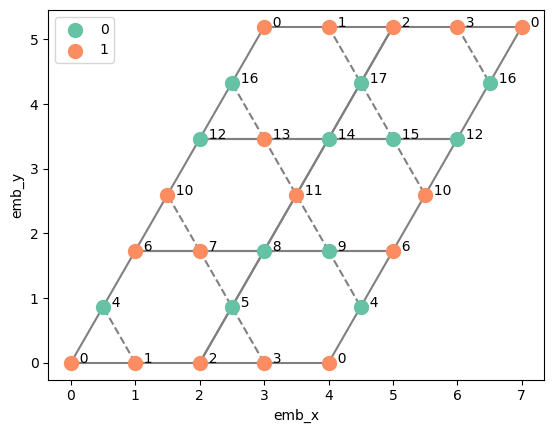

In [129]:
lattice.plot(spins=state)

In [130]:
def inv_perm(perm: list[int]) -> list[int]:
    return (~Permutation(perm)).array_form

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

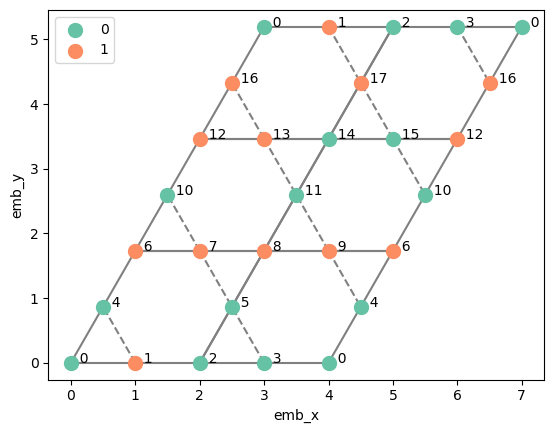

In [131]:
lattice.plot(spins=state[inv_perm(lattice.get_translation("y"))])

In [132]:
group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]

In [133]:
filter_size = 16
filter_idxs = torch.arange(filter_size)

In [134]:
def self_action(g: Permutation) -> Permutation:
    # permutation acts from the right, so it's h * g instead of g * h
    return Permutation([group_elements.index(h * g) for h in group_elements])

In [322]:
class GConvGrid(nn.Module):
    def __init__(
        self, filter_size: int, lattice: SpinLattice, out_channels: int, filter_idxs=None
    ):
        super().__init__()
        self.filter_size = filter_size
        self.out_channels = out_channels
        self.lattice = lattice
        self.filter_idxs = filter_idxs if filter_idxs is not None else torch.arange(filter_size)
        self.group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]
        self.inv_group_elements_tensor = torch.tensor(
            [(~g).array_form for g in self.group_elements], dtype=torch.long
        )
        self.filter = nn.Parameter(
            torch.empty(out_channels, filter_size)
        )  # change from torch.rand to torch.empty
        torch.nn.init.xavier_uniform_(self.filter)  # apply Xavier uniform initialization
        self.filter.requires_grad = True

    def _forward_reference(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros((self.out_channels, self.lattice.number_spins))
        filter_extended[:, self.filter_idxs] = self.filter
        for i, g in enumerate(self.group_elements):
            permuted_filter = filter_extended[:, (~g).array_form]
            output[:, :, i] = torch.einsum("bn,an->ba", batch, permuted_filter)
        return output

    def forward(self, batch: torch.Tensor):
        filter_extended = torch.zeros((self.out_channels, self.lattice.number_spins))
        filter_extended[:, self.filter_idxs] = self.filter

        permuted_filters = filter_extended[:, self.inv_group_elements_tensor.view(-1)].view(
            self.out_channels, len(self.group_elements), self.lattice.number_spins
        )

        output = torch.einsum("bs,ogs->bog", batch, permuted_filters)
        return output

In [267]:
X = torch.tensor(
    make_unpacked_configurations(
        system.basis.states[:10], number_spins=system.number_spins
    ).astype(np.float32),
)
layer = GConvGrid(12, lattice, 3)
layer(X)
assert torch.allclose(layer(X), layer._forward_reference(X), atol=1e-7)

In [324]:
class GConvG(nn.Module):
    def __init__(
        self,
        filter_size: int,
        lattice: SpinLattice,
        in_channels: int,
        out_channels: int,
        filter_idxs=None,
    ):
        super().__init__()
        self.filter_size = filter_size
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.lattice = lattice
        self.filter_idxs = filter_idxs if filter_idxs is not None else torch.arange(filter_size)
        self.group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]
        self.inv_group_elements_tensor = torch.tensor(
            [(~self_action(g)).array_form for g in self.group_elements], dtype=torch.long
        )
        self.filter = nn.Parameter(torch.empty(out_channels, in_channels, filter_size))
        torch.nn.init.xavier_uniform_(self.filter)
        self.filter.requires_grad = True

    def _forward_reference(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros(
            (self.out_channels, self.in_channels, len(self.group_elements))
        )
        filter_extended[:, :, self.filter_idxs] = self.filter

        for action_index, action in enumerate(self.group_elements):
            permuted_filter = filter_extended[:, :, self_action(~action).array_form]
            output[:, :, action_index] = torch.einsum("big,oig->bo", batch, permuted_filter)
            # b: batch, i: in_channels, g: group_elements, o: out_channels

        return output

    def forward(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros(
            (self.out_channels, self.in_channels, len(self.group_elements))
        )
        filter_extended[:, :, self.filter_idxs] = self.filter

        permuted_filters = filter_extended[:, :, self.inv_group_elements_tensor.view(-1)].view(
            self.out_channels,
            self.in_channels,
            len(self.group_elements),
            len(self.group_elements),
        )

        return torch.einsum("big,oiag->boa", batch, permuted_filters)
        # b: batch, i: input channels, g: group element (as domain coordinate)
        # o: output channel, a: group element (as action)

In [325]:
X = torch.tensor(
    make_unpacked_configurations(
        system.basis.states[:10], number_spins=system.number_spins
    ).astype(np.float32),
)

In [328]:
layer1 = GConvGrid(filter_size=filter_size, lattice=lattice, out_channels=3)
layer2 = GConvG(filter_size=9, lattice=lattice, in_channels=3, out_channels=5)
# assert equivariance
X = torch.tensor(
    make_unpacked_configurations(system.basis.states, number_spins=system.number_spins).astype(
        np.float32
    ),
)

def net(X):
    return layer2(layer1(X))

def net_reference(X):
    return layer2._forward_reference(layer1(X))

assert net(X).shape == (len(system.basis.states), 5, len(group_elements))
assert torch.allclose(net(X), net_reference(X), atol=1e-7)
for action in group_elements:
    assert torch.allclose(
        net_reference(X[:, (~action).array_form]),
        net_reference(X)[:, :, self_action(~action).array_form],
        atol=1e-6
    )

In [329]:
class GConvNet2(nn.Module):
    def __init__(self, lattice: SpinLattice, channels1=32, channels2=64):
        super().__init__()
        self.layer1 = GConvGrid(filter_size=16, lattice=lattice, out_channels=channels1)
        self.layer2 = GConvG(
            filter_size=8, lattice=lattice, in_channels=channels1, out_channels=channels2
        )

        tx = Permutation(lattice.get_translation("x"))
        ty = Permutation(lattice.get_translation("y"))
        sym = Permutation([g for g in lattice.get_automorphisms() if g[0] == 0 and g[1] != 1][0])

        self.layer2.filter_idxs = torch.tensor(
            [
                self.layer2.group_elements.index(g)
                for g in [
                    tx**a * ty**b * sym**c for a in [0, 1] for b in [0, 1] for c in [0, 1]
                ]
            ]
        )

        self.fc = nn.Linear(channels2, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = x.mean(dim=2)
        x = self.fc(x)
        return x

In [332]:
def get_X_Y(system: SpinSystem, sample=None, target="amplitude"):
    ground_state_df = system.get_df_ground_state()
    if sample:
        ground_state_df = ground_state_df.sample(sample)
    Y = torch.Tensor(
        np.log(np.real_if_close(ground_state_df[target].to_numpy()).astype(np.float32))
    )
    # Y = Y / Y.mean()
    X = torch.Tensor(
        make_unpacked_configurations(
            ground_state_df.index.to_numpy(), number_spins=system.number_spins
        ).astype(np.float32)
    )
    return X, Y


def overlap(x, y):
    return torch.sum(x * y) / torch.sqrt(torch.sum(x**2) * torch.sum(y**2))

In [336]:
# Test invariance

X, Y = get_X_Y(system)
model = GConvNet2(lattice=lattice)
for g in lattice.get_automorphisms():
    assert torch.allclose(
        model(X[:, g]), model(X), atol=1e-6
    )

In [334]:
X, Y = get_X_Y(system)
# Initialize the model
model = GConvNet2(lattice=lattice)

# Check if a GPU is available and if not, use a CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move the model to the device (GPU or CPU)
model.to(device)

# Create a TensorDataset from your inputs X and Y
dataset = TensorDataset(X, Y)

# Create a DataLoader for your dataset with a batch size of 32 and shuffling
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define a loss function - Mean Squared Error (MSE) for regression
criterion = torch.nn.MSELoss()

# Define an optimizer - Adam
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Learning rate

# Number of epochs (iterations over the entire dataset)
epochs = 500

for epoch in range(epochs):
    running_loss = 0.0
    for action_index, data in enumerate(dataloader, 0):
        # Get the inputs and move them to the specified device
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels.view(-1, 1))  # Reshape labels to match output shape

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        
        # print(f"{loss.item()=}")
        # print(f"Overlap: {overlap(model(X).view(-1), Y)}")
    # Print average loss per epoch
    print(f"Epoch {epoch + 1} loss: {running_loss / len(dataloader)}")
    print(f"Overlap: {overlap(torch.exp(model(X).view(-1)), torch.exp(Y))}")
    # print(f"Overlap target: {overlap(torch.exp(model(X_target).view(-1)), torch.exp(Y_target))}")
    

print("Finished Training")


Epoch 1 loss: 2.198951202983919
Overlap: 0.7931836247444153
Epoch 2 loss: 1.264137862132568
Overlap: 0.8435642123222351
Epoch 3 loss: 1.1974227087866318
Overlap: 0.8808164000511169
Epoch 4 loss: 1.0804005450716143
Overlap: 0.9154114723205566
Epoch 5 loss: 0.923086311628944
Overlap: 0.9011785387992859
Epoch 6 loss: 0.8084914615573852
Overlap: 0.926620602607727


KeyboardInterrupt: 